In [22]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [23]:
train_path = r"Indian currency dataset v1\training"
valid_path = r"Indian currency dataset v1\validation"

In [24]:
train_datagen = ImageDataGenerator(
    validation_split = 0.2,
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True
)

In [25]:
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

In [26]:
train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(128,128),

    batch_size=32,

    class_mode="categorical"

)

validation_generator = validation_datagen.flow_from_directory(

    valid_path,

    target_size=(128,128),

    batch_size=32,

    class_mode="categorical"

)

Found 2735 images belonging to 6 classes.
Found 270 images belonging to 6 classes.


In [27]:
print(train_generator.class_indices)

{'10': 0, '100': 1, '20': 2, '200': 3, '50': 4, '500': 5}


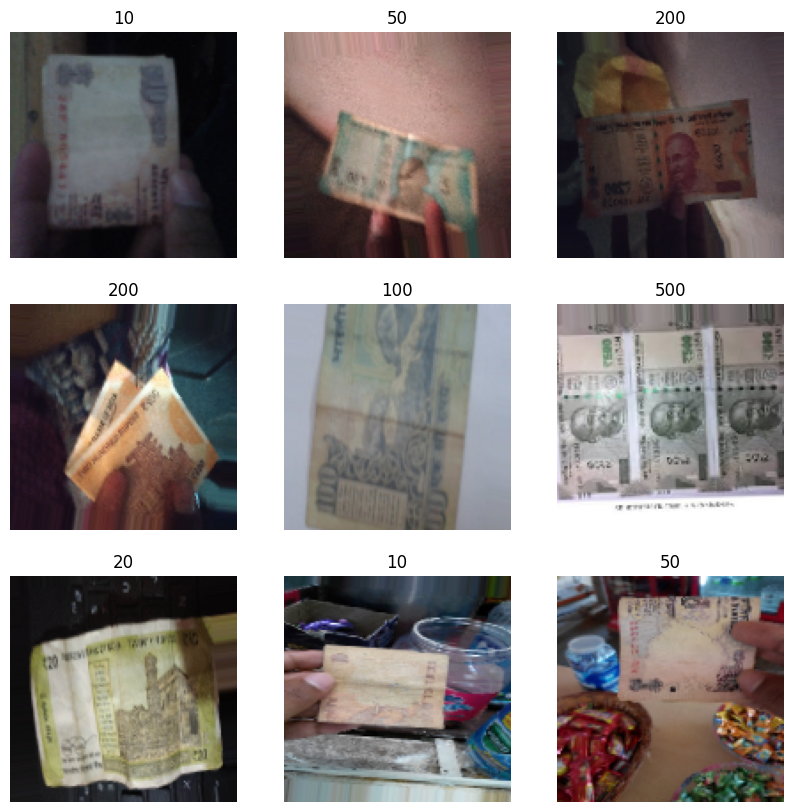

In [28]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

class_names = list(train_generator.class_indices.keys())

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(class_names[np.argmax(labels[i])])

    plt.axis("off")

plt.show()

In [39]:
model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,activation='relu'),
    Dropout(0.5),
    
    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')

])

In [40]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [41]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "currency_model.keras",
    save_best_only=True,
    monitor="val_accuracy"
)

In [42]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 693s 8s/step - accuracy: 0.2669 - loss: 2.2071 - val_accuracy: 0.1667 - val_loss: 1.8636
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 734s 9s/step - accuracy: 0.3477 - loss: 1.6310 - val_accuracy: 0.1778 - val_loss: 1.7445
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.3909 - loss: 1.5341 - val_accuracy: 0.1741 - val_loss: 1.8364
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 324s 4s/step - accuracy: 0.4230 - loss: 1.4602 - val_accuracy: 0.2926 - val_loss: 1.6209
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 328s 4s/step - accuracy: 0.4644 - loss: 1.3675 - val_accuracy: 0.4815 - val_loss: 1.3528


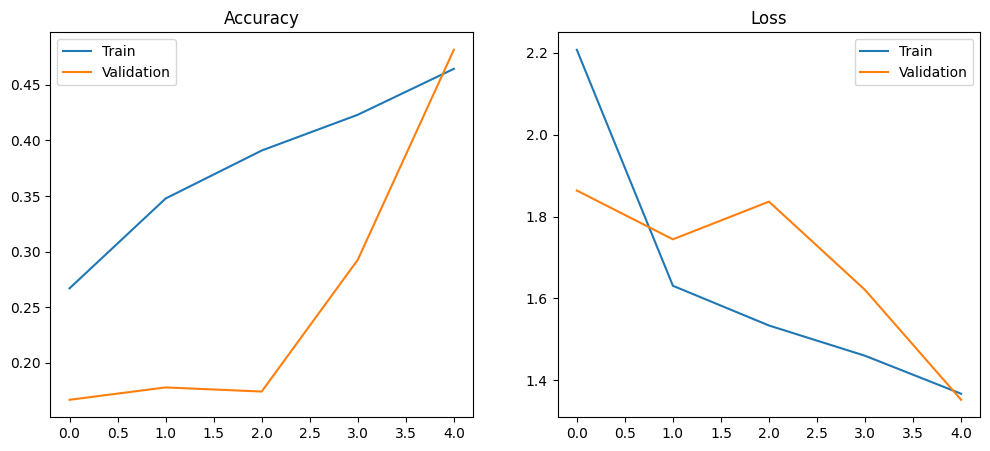

In [43]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [44]:
from tensorflow.keras.preprocessing import image

img = image.load_img("500_val_4.jpg", target_size=(128,128))

img_array = image.img_to_array(img) / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

class_names = list(train_generator.class_indices.keys())

confidence = np.max(prediction) * 100

print("Predicted Note:", class_names[predicted_index])

print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
Predicted Note: 500
Confidence: 74.55%


In [45]:
print("Training Accuracy :", history.history['accuracy'][-1])
print("Validation Accuracy :", history.history['val_accuracy'][-1])

Training Accuracy : 0.46435099840164185
Validation Accuracy : 0.48148149251937866


In [46]:
prediction = model.predict(img_array)

class_names = list(train_generator.class_indices.keys())

for i, prob in enumerate(prediction[0]):
    print(f"{class_names[i]} : {prob*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
10 : 4.82%
100 : 1.78%
20 : 8.60%
200 : 3.03%
50 : 7.23%
500 : 74.55%


In [47]:
model.save("currency.keras")

print("Model saved successfully!")

Model saved successfully!
